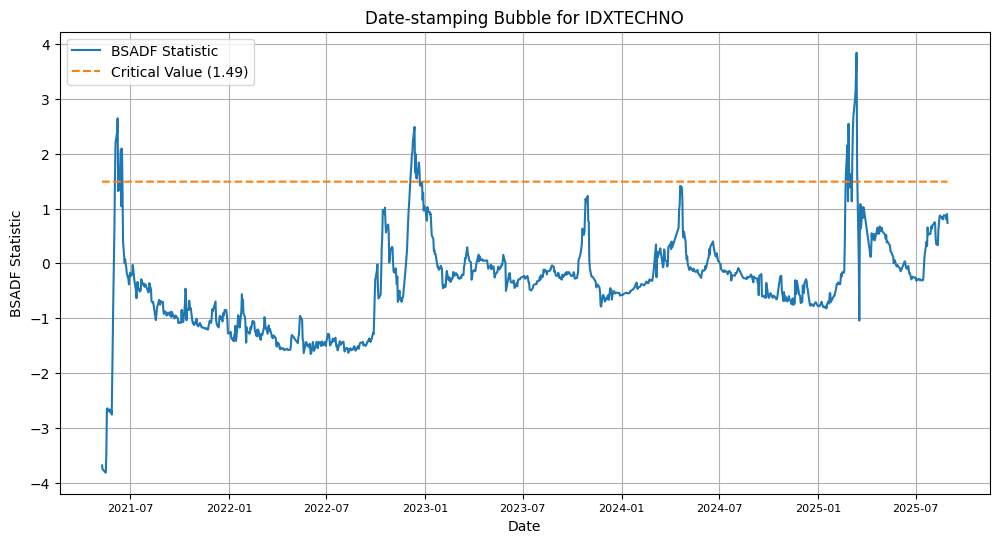

Dates when bubbles were detected:
DatetimeIndex(['2021-06-03', '2021-06-04', '2021-06-07', '2021-06-08',
               '2021-06-10', '2021-06-14', '2021-06-16', '2022-12-05',
               '2022-12-06', '2022-12-07', '2022-12-08', '2022-12-09',
               '2022-12-12', '2022-12-13', '2022-12-14', '2022-12-15',
               '2022-12-16', '2022-12-19', '2022-12-20', '2022-12-21',
               '2025-02-21', '2025-02-24', '2025-02-26', '2025-02-27',
               '2025-03-03', '2025-03-05', '2025-03-06', '2025-03-07',
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14'],
              dtype='datetime64[ns]', name='Tahun', freq=None)


In [1]:
#importing packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

#this is a bubble detecting algorithm developed by Phillips and Yu (2011) and Phillips et al. (2015)
#it is based on the augmented Dickey-Fuller test

#inputting the parameters
excel_file = '/content/Dataset Skripsi.xlsx'
sheet_name = 'HARIAN'
variable_name = 'TECH'
start = '2021-01-26'
end = '2025-08-29'
#minimum window size
r0 = 70
#specify lags for the augmented Dickey-Fuller (ADF) test
adf_lags = 2
#critical value of the right-tailed ADF-test (95%) from Phillips et al. (2015)
crit = 1.49

#load & filter data
df_raw = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
df_raw.columns = df_raw.iloc[2]
df = df_raw[3:].copy()

if 'Tahun' in df.columns:
    df['Tahun'] = pd.to_datetime(df['Tahun'])
    df = df.set_index('Tahun')
    df[variable_name] = df[variable_name].astype(str).str.replace(',', '.', regex=False).astype(float)
    df = df[(df.index >= start) & (df.index <= end)]
    prices = df[variable_name]
else:
    raise KeyError("Kolom 'Tahun' tidak ditemukan.")

# #transforming data
log_prices = np.array(np.log(prices.values))
delta_log_prices = log_prices[1:] - log_prices[:-1]
n = len(delta_log_prices)
BSADF = np.array([])
#calculating ADF stats
for r2 in range(r0, n):
    ADFS = np.array([])
    for r1 in range(0, r2 - r0 + 1):
        X_0 = log_prices[r1:r2 + 1]
        X = pd.DataFrame()
        X[0] = X_0
        for j in range(1, adf_lags + 1):
            X[j] = np.append(np.zeros(j), delta_log_prices[r1:r2 + 1 - j])
        X = np.array(X)
        y = delta_log_prices[r1:r2 + 1]

        reg = sm.OLS(y, sm.add_constant(X))
        res = reg.fit()
        ADFS = np.append(ADFS, res.params[1] / res.bse[1])

    BSADF = np.append(BSADF, max(ADFS))

# visualising the results
plt.rc('xtick', labelsize=8)
plt.figure(figsize=(12, 6))
plt.plot(prices.index[r0 + 1:], BSADF, label='BSADF Statistic')
plt.plot(prices.index[r0 + 1:], np.ones(len(BSADF)) * crit, label=f'Critical Value ({crit})', linestyle='--')
plt.title(f'Date-stamping Bubble for IDXTECHNO')
plt.xlabel('Date')
plt.ylabel('BSADF Statistic')
plt.legend()
plt.grid(True)
plt.show()
#printing dates when bubbles were detected
print("Dates when bubbles were detected:")
print(prices.index[r0 + 1:][BSADF > crit])